# 02 Metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss, f1_score,
    log_loss, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)

In [2]:
df = pd.read_csv("../data/raw/train_transaction.csv",
                 usecols=["isFraud", "TransactionDT", "TransactionAmt"])

y = df["isFraud"].to_numpy()
amt = df["TransactionAmt"].to_numpy()
n = len(y)
n_pos = y.sum()
base_rate = y.mean()
pos_idx = np.flatnonzero(y == 1)
neg_idx = np.flatnonzero(y == 0)

rng = np.random.default_rng(42)

print(n, n_pos, base_rate)

590540 20663 0.03499000914417313


## Threshold metrics

In [3]:
predictors = {
    "always 0": np.zeros(n),
    "random": rng.uniform(size=n),
    "perfect": y.astype(float),
    "perfect, squashed": np.where(y == 1, 0.51, 0.49),
    "perfect, inverted": 1.0 - y,
}

rows = []
for name, s in predictors.items():
    pred = (s >= 0.5).astype(int)
    rows.append({
        "predictor": name,
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, s),
        "PR-AUC": average_precision_score(y, s),
    })

pd.DataFrame(rows).set_index("predictor").round(3)

,accuracy,precision,recall,F1,ROC-AUC,PR-AUC
predictor,,,,,,
always 0,0.965,0.000,0.000,0.000,0.500,0.035
random,0.500,0.035,0.498,0.065,0.499,0.035
perfect,1.000,1.000,1.000,1.000,1.000,1.000
"perfect, squashed",1.000,1.000,1.000,1.000,1.000,1.000
"perfect, inverted",0.000,0.000,0.000,0.000,0.000,0.035


Accuracy is useless here: "always 0" already gets 96.5%. AUC only depends on the order of scores.

### 95% accuracy with 10% precision and recall

In [4]:
flag = np.zeros(n, dtype=int)
tp = int(0.10 * n_pos)
flag[rng.choice(pos_idx, tp, replace=False)] = 1
flag[rng.choice(neg_idx, n_pos - tp, replace=False)] = 1

always0 = np.zeros(n, dtype=int)

q1 = pd.DataFrame({
    "10% model": {
        "accuracy": accuracy_score(y, flag),
        "precision": precision_score(y, flag),
        "recall": recall_score(y, flag),
        "F1": f1_score(y, flag),
    },
    "always 0": {
        "accuracy": accuracy_score(y, always0),
        "precision": precision_score(y, always0, zero_division=0),
        "recall": recall_score(y, always0),
        "F1": f1_score(y, always0, zero_division=0),
    },
})
q1.round(3)

,10% model,always 0
accuracy,0.937,0.965
precision,0.100,0.000
recall,0.100,0.000
F1,0.100,0.000


Bad: it is worse than "always 0" and misses 90% of fraud.

### F1 macro vs F1 micro

In [5]:
for name, pred in [("always 0", always0), ("10% model", flag)]:
    micro = f1_score(y, pred, average="micro")
    macro = f1_score(y, pred, average="macro")
    print(name, "micro:", round(micro, 3), "macro:", round(macro, 3))

y_true = np.array([0] * 45 + [1] * 45 + [2, 2, 3, 3, 4, 4, 5, 5, 6, 6])
y_pred = np.array([0] * 22 + [1] * 23 + [0] * 23 + [1] * 22 + [2, 2, 3, 3, 4, 4, 5, 5, 6, 6])

micro = f1_score(y_true, y_pred, average="micro")
macro = f1_score(y_true, y_pred, average="macro")
print("toy example micro:", round(micro, 3), "macro:", round(macro, 3))

always 0 micro: 0.965 macro: 0.491
10% model micro: 0.937 macro: 0.534
toy example micro: 0.54 macro: 0.854


Micro F1 is bigger when the model is good on big classes, macro F1 in the opposite case.

## What ROC-AUC measures

In [6]:
SHIFT = 1.466
s_demo = rng.normal(size=n) + SHIFT * y

pos_s = s_demo[y == 1]
neg_s = s_demo[y == 0]
i = rng.integers(0, len(pos_s), 1_000_000)
j = rng.integers(0, len(neg_s), 1_000_000)
pairwise = (pos_s[i] > neg_s[j]).mean() + 0.5 * (pos_s[i] == neg_s[j]).mean()

print(f"theory: {norm.cdf(SHIFT / np.sqrt(2)):.4f}")
print(f"sklearn: {roc_auc_score(y, s_demo):.4f}")
print(f"1M pairs: {pairwise:.4f}")

theory: 0.8500
sklearn: 0.8508
1M pairs: 0.8511


All three ways give the same AUC: the probability that a random fraud scores higher than a random legit transaction.

## Class imbalance

In [7]:
rows = []
for target in [base_rate, 0.10, 0.25, 0.50]:
    n_neg = int(n_pos * (1 - target) / target)
    n_neg = min(n_neg, len(neg_idx))
    legit_sample = rng.choice(neg_idx, n_neg, replace=False)
    idx = np.concatenate([pos_idx, legit_sample])
    rows.append({
        "base rate": y[idx].mean(),
        "rows": len(idx),
        "ROC-AUC": roc_auc_score(y[idx], s_demo[idx]),
        "PR-AUC": average_precision_score(y[idx], s_demo[idx]),
    })

imbalance = pd.DataFrame(rows)
imbalance.round(3)

,base rate,rows,ROC-AUC,PR-AUC
0,0.035,590540,0.851,0.260
1,0.100,206630,0.851,0.466
2,0.250,82652,0.851,0.683
3,0.500,41326,0.850,0.848


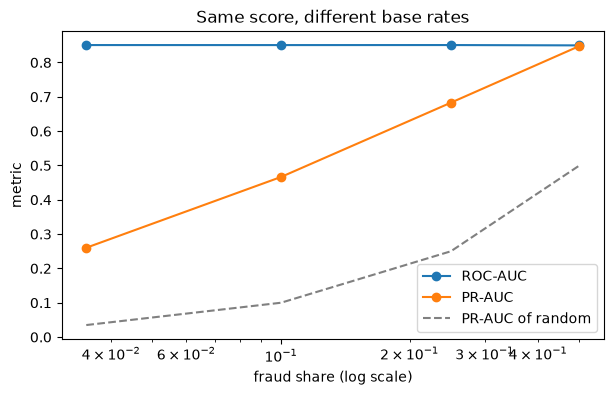

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(imbalance["base rate"], imbalance["ROC-AUC"], "o-", label="ROC-AUC")
ax.plot(imbalance["base rate"], imbalance["PR-AUC"], "o-", label="PR-AUC")
ax.plot(imbalance["base rate"], imbalance["base rate"], "--", color="gray", label="PR-AUC of random")
ax.set_xscale("log")
ax.set_xlabel("fraud share (log scale)")
ax.set_ylabel("metric")
ax.set_title("Same score, different base rates")
ax.legend()
plt.show()

ROC-AUC doesn't depend on the fraud rate, PR-AUC does.

## Same ROC-AUC, different usefulness

In [9]:
def precision_at_k(y_true, score, frac):
    k = int(frac * len(score))
    top = np.argsort(-score)[:k]
    return y_true[top].mean()


def recall_at_fpr(y_true, score, max_fpr):
    fpr, tpr, _ = roc_curve(y_true, score)
    return tpr[fpr <= max_fpr].max()


def amount_recall_at_k(y_true, score, amount, frac):
    k = int(frac * len(score))
    top = np.argsort(-score)[:k]
    return (amount[top] * y_true[top]).sum() / (amount * y_true).sum()


def ranking_metrics(y_true, score, amount):
    return {
        "ROC-AUC": roc_auc_score(y_true, score),
        "PR-AUC": average_precision_score(y_true, score),
        "pAUC (FPR<=1%)": roc_auc_score(y_true, score, max_fpr=0.01),
        "Recall @ FPR=1%": recall_at_fpr(y_true, score, 0.01),
        "Precision @ top 1%": precision_at_k(y_true, score, 0.01),
        "$ recall @ top 1%": amount_recall_at_k(y_true, score, amount, 0.01),
    }

In [10]:
sharp_hit = (y == 1) & (rng.uniform(size=n) < 0.5)
s_sharp = rng.normal(size=n)
s_sharp[sharp_hit] = rng.normal(4.0, 0.5, size=sharp_hit.sum())
target_auc = roc_auc_score(y, s_sharp)

noise_flat = rng.normal(size=n)
lo, hi = 0.0, 3.0
for _ in range(25):
    mid = (lo + hi) / 2
    if roc_auc_score(y, noise_flat + mid * y) < target_auc:
        lo = mid
    else:
        hi = mid
s_flat = noise_flat + hi * y

same_auc = pd.DataFrame({
    "sharp": ranking_metrics(y, s_sharp, amt),
    "flat": ranking_metrics(y, s_flat, amt),
})
same_auc["ratio"] = same_auc["sharp"] / same_auc["flat"]
same_auc.round(3)

,sharp,flat,ratio
ROC-AUC,0.750,0.750,1.000
PR-AUC,0.540,0.120,4.491
pAUC (FPR<=1%),0.746,0.522,1.429
Recall @ FPR=1%,0.505,0.083,6.103
Precision @ top 1%,0.996,0.243,4.100
$ recall @ top 1%,0.286,0.070,4.066


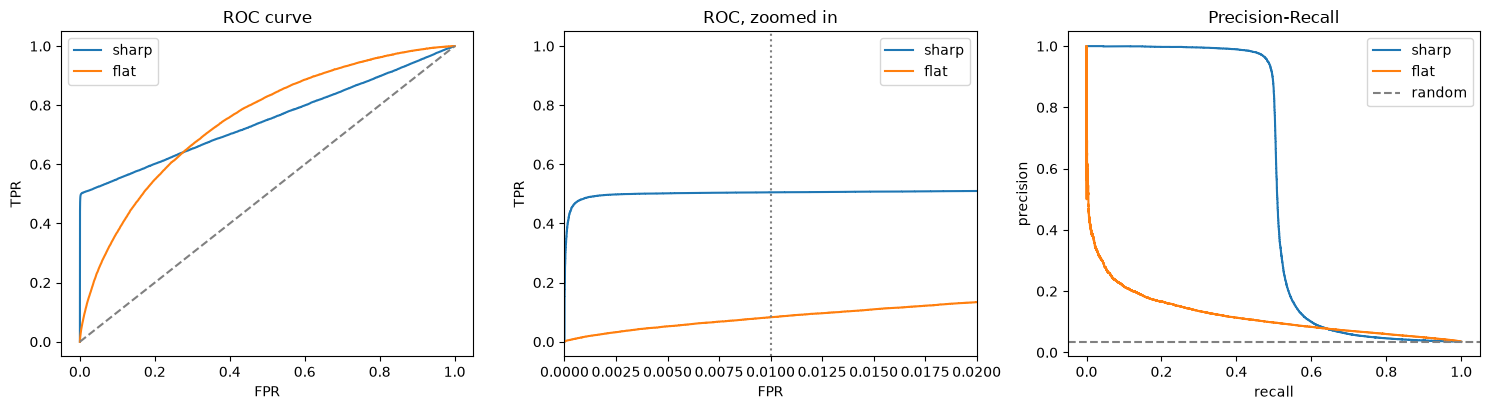

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for name, s in [("sharp", s_sharp), ("flat", s_flat)]:
    fpr, tpr, _ = roc_curve(y, s)
    prec, rec, _ = precision_recall_curve(y, s)
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(fpr, tpr, label=name)
    axes[2].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("ROC curve")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")

axes[1].set_xlim(0, 0.02)
axes[1].axvline(0.01, color="gray", ls=":")
axes[1].set_title("ROC, zoomed in")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")

axes[2].axhline(base_rate, color="gray", ls="--", label="random")
axes[2].set_title("Precision-Recall")
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")

for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

With the same AUC, the sharp model catches 50% of fraud at 1% false alarms and the flat one only 8%.

## Calibration

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


num = base_rate * norm.pdf(s_demo - SHIFT)
p_cal = num / (num + (1 - base_rate) * norm.pdf(s_demo))
logit = np.log(p_cal / (1 - p_cal))

versions = {
    "calibrated": p_cal,
    "overconfident": sigmoid(3 * logit),
    "underconfident": sigmoid(0.3 * logit),
    "rank": pd.Series(s_demo).rank(pct=True).to_numpy(),
}

rows = []
for name, p in versions.items():
    rows.append({
        "version": name,
        "ROC-AUC": roc_auc_score(y, p),
        "PR-AUC": average_precision_score(y, p),
        "log loss": log_loss(y, p),
        "Brier": brier_score_loss(y, p),
        "mean predicted": p.mean(),
    })

pd.DataFrame(rows).set_index("version").round(4)

,ROC-AUC,PR-AUC,log loss,Brier,mean predicted
version,,,,,
calibrated,0.8508,0.2602,0.1174,0.0294,0.0350
overconfident,0.8508,0.2602,0.2452,0.0322,0.0056
underconfident,0.8508,0.2602,0.2833,0.0674,0.2246
rank,0.8508,0.2602,0.9117,0.3096,0.5000


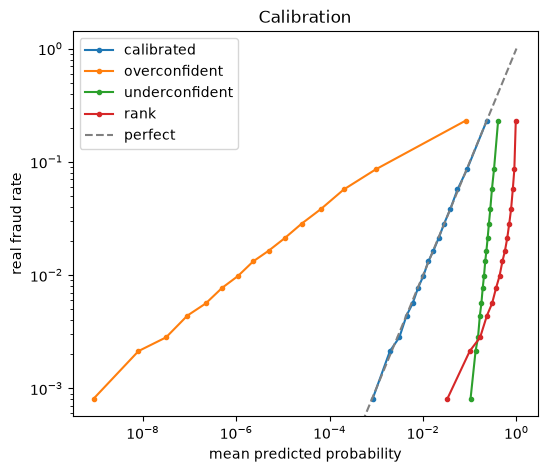

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, p in versions.items():
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=15, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", ms=3, label=name)
ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("real fraud rate")
ax.set_title("Calibration")
ax.legend()
plt.show()

AUC doesn't show if the probabilities make sense.

## Edge cases

In [14]:
s_round = np.round(s_demo)

print("continuous:", roc_auc_score(y, s_demo))
print("rounded:", roc_auc_score(y, s_round), "distinct values:", len(np.unique(s_round)))
print("negated:", roc_auc_score(y, -s_demo))

continuous: 0.8508171005170698
rounded: 0.8316167465798816 distinct values: 11
negated: 0.14918289948293018


Ties lower the AUC, and flipping the score gives 1 - AUC.

In [15]:
print(roc_auc_score(y[neg_idx[:1000]], s_demo[neg_idx[:1000]]))

day = df["TransactionDT"] // 86400
hour = df["TransactionDT"] // 3600

fraud_per_day = df.groupby(day)["isFraud"].sum()
fraud_per_hour = df.groupby(hour)["isFraud"].sum()

print("min fraud per day:", fraud_per_day.min())
print("hours without fraud:", (fraud_per_hour == 0).sum(), "of", len(fraud_per_hour))

nan
min fraud per day: 51
hours without fraud: 726 of 4368


/Users/maksym.pasko/Desktop/deep_learning_01/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


AUC can't be computed without fraud cases, so it works per day but not per hour.

In [16]:
def bootstrap_auc(y_true, score, n_boot):
    m = len(y_true)
    aucs = []
    for _ in range(n_boot):
        idx = rng.integers(0, m, m)
        aucs.append(roc_auc_score(y_true[idx], score[idx]))
    return np.array(aucs)


windows = {
    "one day": (day == 100).to_numpy(),
    "last 20% of time": (day >= day.quantile(0.8)).to_numpy(),
}

rows = []
for name, mask in windows.items():
    aucs = bootstrap_auc(y[mask], s_demo[mask], 200)
    rows.append({
        "window": name,
        "rows": mask.sum(),
        "fraud": y[mask].sum(),
        "AUC": roc_auc_score(y[mask], s_demo[mask]),
        "CI low": np.percentile(aucs, 2.5),
        "CI high": np.percentile(aucs, 97.5),
    })

boot = pd.DataFrame(rows).set_index("window")
boot["CI width"] = boot["CI high"] - boot["CI low"]
boot.round(4)

,rows,fraud,AUC,CI low,CI high,CI width
window,,,,,,
one day,3052,100,0.8743,0.8413,0.9096,0.0683
last 20% of time,118534,4073,0.8551,0.8497,0.8604,0.0106


On 118k rows the noise is about ±0.005, so smaller differences don't mean much.

## Summary

- Accuracy doesn't work for this data.
- ROC-AUC is stable when the fraud rate changes, but ignores calibration and the top of the list.
- ROC-AUC stays the main metric, PR-AUC would be the alternative.